## day2 scRNA-seq実習
初日に使用したdataset (GEO Accession GSE278962)のT cell subsetを、Seuratオブジェクトの中身を理解しながら実施する
初日のT cell subsetの実習内容を掘り下げて詳しく説明した回です。

## step1 packageの読み込み
installしたpackageはlibrary()で読み込まないと利用できない。

下記は、\
library(Seurat)\
library(BiocStyle)\
,,,\
と同じです。

In [1]:

packages <- c("Seurat", "BiocStyle", "patchwork",
              "dplyr", "magrittr", "knitr", "rmarkdown")

for (pkg in packages) {
  tryCatch({
    library(pkg, character.only = TRUE)
    cat(sprintf("  ✓ %-15s : %s\n", pkg, packageVersion(pkg)))
  }, error = function(e) {
    cat(sprintf("  ✗ %-15s : インストールされていません！\n", pkg))
  })
}



 要求されたパッケージ SeuratObject をロード中です 

 要求されたパッケージ sp をロード中です 


 次のパッケージを付け加えます: ‘SeuratObject’ 


 以下のオブジェクトは ‘package:base’ からマスクされています:

    intersect, t




  ✓ Seurat          : 5.2.1
  ✓ BiocStyle       : 2.30.0
  ✓ patchwork       : 1.3.2



 次のパッケージを付け加えます: ‘dplyr’ 


 以下のオブジェクトは ‘package:stats’ からマスクされています:

    filter, lag


 以下のオブジェクトは ‘package:base’ からマスクされています:

    intersect, setdiff, setequal, union




  ✓ dplyr           : 1.1.4
  ✓ magrittr        : 2.0.3
  ✓ knitr           : 1.45



 次のパッケージを付け加えます: ‘rmarkdown’ 


 以下のオブジェクトは ‘package:BiocStyle’ からマスクされています:

    html_document, md_document, pdf_document




  ✓ rmarkdown       : 2.25


## step2 seuratオブジェクトの読み込み
seuratオブジェクトはrdsファイルの形式で保存されていることが多いです。\
rdsファイルはreadRDSで読み込めます。

In [2]:
# Adjust path if necessary
input_file <- "./JIAsyno_CITEseq_T_NK.rds"

if (!file.exists(input_file)) {
  stop("Input file not found. Please run Part 1 first or check the file path.")
}

t_cells <- readRDS(input_file)
print(t_cells)

An object of class Seurat 
58685 features across 10841 samples within 3 assays 
Active assay: RNA (30803 features, 2000 variable features)
 3 layers present: scale.data, data, counts
 2 other assays present: ADT, SCT
 4 dimensional reductions calculated: pca, harmony, umap, symphony_umap


In [3]:
## 実習の前にSeuratオブジェクトから処理後のdataをのぞいています。 (普通の解析では不要です)
t_cells_slim <- DietSeurat(t_cells,
                           layers = c("counts"),
                           dimreducs = NULL,
                           graphs = NULL
)
t_cells_slim[["SCT"]] <- NULL
t_cells_slim[["ADT"]] <- NULL

##　実習0
① 現在自分がいるフォルダはどこですか。 \
② フォルダを変えるにはどうすればいいですか。

In [4]:
getwd()
setwd("~/Desktop/SingleCellWorkshop")

[1] "/Users/haruka_riken/Desktop/SingleCellWorkshop"

## 実習1
t_cells_slimとt_cellsで中身がどう違うか確認してください。

In [5]:
###答え

print(t_cells)
print(t_cells_slim)

###解説
#t_cellsはRNAとADT(タンパク質) の情報、処理後データ (SCT, scale.data, data)、次元削減や統合data(pca, harmony, umap, symphony_umap)　を含む。
#t_cells_slimはRNAのcount情報およびmeta.tada情報のみになっている 


An object of class Seurat 
58685 features across 10841 samples within 3 assays 
Active assay: RNA (30803 features, 2000 variable features)
 3 layers present: scale.data, data, counts
 2 other assays present: ADT, SCT
 4 dimensional reductions calculated: pca, harmony, umap, symphony_umap
An object of class Seurat 
30803 features across 10841 samples within 1 assay 
Active assay: RNA (30803 features, 2000 variable features)
 1 layer present: counts


## 実習2
t_cells_slimから① metadata ② countデータ
を取り出して、それぞれdataframeに格納してください。

In [6]:
###答え

#① metadata
meta_df=t_cells_slim@meta.data
head(meta_df)
dim(meta_df)
#② countデータ
counts_dense_df <- as.matrix(GetAssayData(t_cells_slim, layer = "counts"))

###解説

## 注意:下記はsparce matrixであり、通常のdata.frameに対する関数が使用できない。
counts_df <- t_cells_slim[["RNA"]]$counts

#処理が重い場合down-sampling
set.seed(42)  # 再現性のため
cells <- sample(colnames(t_cells_slim), size = 1000)
t_cells_sub <- t_cells_slim[, cells]
counts_sub_dense_df <- as.matrix(GetAssayData(t_cells_sub, layer = "counts"))

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_Protein,nFeature_Protein,T_clonotype_id,T_cdr3s_aa,B_clonotype_id,B_cdr3s_aa,⋯,label15s,nCount_ADT,nFeature_ADT,ct,ct_subtype,nCount_SCT,nFeature_SCT,SCT_snn_res.0.5,major_cell_type,symphony_pred_type
,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>,<int>,<fct>,<fct>,<fct>
AAACCTGCACCCATTC-1_1,PBMC1,5601,1657,1.963935,294,95,clonotype8792,TRB:CASSQVGRFSGNTIYF;TRA:CAVGNNAGNMLTF,NA,NA,⋯,CD4+ T cells,294,95,CD4+ T,CD4+ KLRB1+ memory T,3105,1445,1,T/NK,T cell
AAAGATGTCAGCTCGG-1_1,PBMC1,2103,871,2.853067,314,92,clonotype5584,TRB:CASSYWGGRFDEQFF;TRA:CASRRGNQFYF,NA,NA,⋯,CD4+ T cells,314,92,CD4+ T,CD4+ naive/central memory T,2340,861,1,T/NK,T cell
AAAGCAAAGCCAGTAG-1_1,PBMC1,2403,824,2.746567,364,101,clonotype4459,TRB:CASSRQSGSYNEQFF;TRB:CASSSVAGQGETEQFF;TRA:CAMRANTGGFKTIF,NA,NA,⋯,CD4+ T cells,364,101,CD4+ T,CD4+ naive/central memory T,2457,810,1,T/NK,T cell
AAAGCAATCGAACTGT-1_1,PBMC1,2754,1136,2.723312,288,95,NA,NA,NA,NA,⋯,CD4+ T cells,288,95,CD4+ T,CD4+ naive/central memory T,2631,1122,1,T/NK,T cell
AAAGTAGCAAAGTGCG-1_1,PBMC1,1963,797,1.732043,311,88,clonotype969,TRB:CSANLAGVYNEQFF,NA,NA,⋯,CD4+ T cells,311,88,CD4+ T,CD4+ naive/central memory T,2305,793,1,T/NK,T cell
AAATGCCAGCGTTCCG-1_1,PBMC1,2439,908,2.583026,315,95,clonotype4877,TRB:CASSPMAVNEKLFF,NA,NA,⋯,CD4+ T cells,315,95,CD4+ T,CD4+ naive/central memory T,2475,901,1,T/NK,T cell


[1] 10841    45

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.5 GiB”


In [7]:
DefaultAssay(t_cells_slim) <- "RNA"

# 1. Normalize (if not already done, but good practice to ensure)
t_cells_slim <- NormalizeData(t_cells_slim)

Normalizing layer: counts



## 実習3
① この作業 (NormalizeData) でできたoutputを確認してください。

② この作業と同様の処理をNormalizeDataを使わずに実施してください。


In [8]:
### 答え
#①
t_cells_slim[["RNA"]]$data

#②
head(counts_dense_df)
sum_count=apply(counts_dense_df,2,sum)

result <- log(sweep(counts_dense_df, 2, sum_count/10000, "/")+1)
result[1:10,1]
result[1:10,1:20]

###解説

#ここでは、a) 細胞間のUMI数=カウント数で補正 (細胞あたりのread depthによる実験ノイズを補正) b) log化 (カウントデータを正規分布に近づける)
#している。
#細胞毎に処理していることがポイント
#*カウントデータは非負の離散データである。データを見た時に、負の値を取るか、連続値か離散データかを意識することは重要。今回のように、扱いやすい分布に近づけ
#たり、適切な線型予測子を選び一般化線型モデルを適用するなど、一工夫要するか判断に役立つ。

  [[ suppressing 32 column names ‘AAACCTGCACCCATTC-1_1’, ‘AAAGATGTCAGCTCGG-1_1’, ‘AAAGCAAAGCCAGTAG-1_1’ ... ]]

  [[ suppressing 32 column names ‘AAACCTGCACCCATTC-1_1’, ‘AAAGATGTCAGCTCGG-1_1’, ‘AAAGCAAAGCCAGTAG-1_1’ ... ]]

  [[ suppressing 32 column names ‘AAACCTGCACCCATTC-1_1’, ‘AAAGATGTCAGCTCGG-1_1’, ‘AAAGCAAAGCCAGTAG-1_1’ ... ]]



30803 x 10841 sparse Matrix of class "dgCMatrix"
                                                                                    
AL627309.1   .        .        .        .        .        .        .        .       
AL627309.5   .        .        .        .        .        .        .        .       
LINC01409    .        .        .        .        .        .        .        .       
LINC01128    .        .        .        .        .        .        .        .       
LINC00115    .        .        .        .        .        .        .        .       
FAM41C       .        .        .        .        .        .        .        .       
NOC2L        1.024390 .        .        .        .        .        .        .       
KLHL17       .        .        .        .        .        .        .        .       
PLEKHN1      .        .        .        .        .        .        .        .       
HES4         .        .        .        .        .        .        .        .       
ISG15        .  

,AAACCTGCACCCATTC-1_1,AAAGATGTCAGCTCGG-1_1,AAAGCAAAGCCAGTAG-1_1,AAAGCAATCGAACTGT-1_1,AAAGTAGCAAAGTGCG-1_1,AAATGCCAGCGTTCCG-1_1,AAATGCCAGCTTCGCG-1_1,AACACGTAGAGCTTCT-1_1,AACACGTCAGACAAAT-1_1,AACCGCGGTGATGTGG-1_1,⋯,GTCACAAAGTGCGATG-1_28,GTGCAGCGTGATGCCC-1_28,GTGTTAGGTAAAGTCA-1_28,TACTTACAGATCGATA-1_28,TGCGTGGAGATAGTCA-1_28,TGCGTGGTCTTAACCT-1_28,TGTATTCCATACGCCG-1_28,TTCTCCTTCACCATAG-1_28,TTGGCAATCCGTTGTC-1_28,TTTGGTTTCCGCGCAA-1_28
AL627309.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
AL627309.5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LINC01409,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LINC01128,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,1,0,0,0
LINC00115,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,1,0
FAM41C,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


AL627309.1 AL627309.5  LINC01409  LINC01128  LINC00115     FAM41C      NOC2L 
   0.00000    0.00000    0.00000    0.00000    0.00000    0.00000    1.02439 
    KLHL17    PLEKHN1       HES4 
   0.00000    0.00000    0.00000

,AAACCTGCACCCATTC-1_1,AAAGATGTCAGCTCGG-1_1,AAAGCAAAGCCAGTAG-1_1,AAAGCAATCGAACTGT-1_1,AAAGTAGCAAAGTGCG-1_1,AAATGCCAGCGTTCCG-1_1,AAATGCCAGCTTCGCG-1_1,AACACGTAGAGCTTCT-1_1,AACACGTCAGACAAAT-1_1,AACCGCGGTGATGTGG-1_1,AACCGCGTCCACGAAT-1_1,AACCGCGTCCTATGTT-1_1,AACGTTGAGTTACCCA-1_1,AACGTTGCATGGTAGG-1_1,AACGTTGGTCGAGTTT-1_1,AACGTTGGTGAAGGCT-1_1,AACGTTGGTGCACGAA-1_1,AACGTTGGTTGTTTGG-1_1,AACTCAGAGCGAGAAA-1_1,AACTCCCAGAGAACAG-1_1
AL627309.1,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,0.00000,0,0
AL627309.5,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,0.00000,0,0
LINC01409,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,1.10749,0,0
LINC01128,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,2.019685,0.8687342,0,0.000000,0,0.00000,0,0
LINC00115,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,0.00000,0,0
FAM41C,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,0.00000,0,0
NOC2L,1.02439,0,0,0,0,0,0,0,0,0,0,1.724247,0.000000,0.0000000,0,0.000000,0,1.10749,0,0
KLHL17,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,1.437283,0,0.00000,0,0
PLEKHN1,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,0.00000,0,0
HES4,0.00000,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.0000000,0,0.000000,0,0.00000,0,0


In [9]:
t_cells_slim <- FindVariableFeatures(t_cells_slim, selection.method = "vst", nfeatures = 2000)
t_cells_slim
t_cells_slim <- ScaleData(t_cells_slim)
t_cells_slim

Finding variable features for layer counts



An object of class Seurat 
30803 features across 10841 samples within 1 assay 
Active assay: RNA (30803 features, 2000 variable features)
 2 layers present: counts, data

Centering and scaling data matrix



An object of class Seurat 
30803 features across 10841 samples within 1 assay 
Active assay: RNA (30803 features, 2000 variable features)
 3 layers present: counts, data, scale.data

## 実習4
① scaleDataでできたoutputを確認してください。

② scaleDataと同様の処理をscaleDataを使わずに実施してください。

In [ ]:
### 答え
#①
t_cells_slim[["RNA"]]$scale.data[1:10,1:10]

#② 
counts_sub_dense_after_norm_df=t_cells_slim[["RNA"]]$data

result2=apply(counts_sub_dense_after_norm_df, 1, scale)
t_cells_slim[["RNA"]]$scale.data["HES4",1:10]
result2[1:10,"HES4"] %>% t()

In [10]:
##パソコンのメモリが小さくて処理できない場合
#細胞数が1000のt_cells_subを作って処理してみる。
set.seed(42)  # 再現性のため
cells <- sample(colnames(t_cells_slim), size = 1000)
t_cells_sub <- t_cells_slim[, cells]

#① (実習3のNormalizeDataから再開)
t_cells_sub <- NormalizeData(t_cells_sub)
t_cells_sub <- FindVariableFeatures(t_cells_sub, selection.method = "vst", nfeatures = 2000)
t_cells_sub <- ScaleData(t_cells_sub)
t_cells_sub[["RNA"]]$scale.data[1:10,1:10]

#②
counts_sub_dense_df <- as.matrix(GetAssayData(t_cells_sub, layer = "counts"))
sum_count=apply(counts_sub_dense_df,2,sum)

counts_sub_dense_after_norm_df <- log(sweep(counts_sub_dense_df, 2, sum_count/10000, "/")+1)
result2=apply(counts_sub_dense_after_norm_df, 1, scale)
result2[1:10,"HES4"] %>% t()

###解説
#scale関数は平均0、分散1にする関数である。geneは発現量にばらつきがあり、発現量が多いgeneは分散も大きくなりやすく、
#処理をしないと発現量が大きいgeneばかり特徴として捉えられてしまう。
#それを避けるために、gene毎に!(大事です) scaleする。

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”


,AAAGATGTCAGCTCGG-1_1,AACGTTGGTGAAGGCT-1_1,AACTCAGAGCGAGAAA-1_1,AACTCTTTCTGATACG-1_1,AAGACCTCACATGTGT-1_1,AATCCAGCAATAGCGG-1_1,ACAGCCGTCTTGTACT-1_1,ACATACGGTTAAGGGC-1_1,ACATGGTAGCTGAACG-1_1,ACGAGGAAGAAGCCCA-1_1
HES4,-0.11421453,-0.11421453,-0.11421453,-0.11421453,-0.11421453,-0.11421453,-0.11421453,-0.11421453,-0.11421453,-0.11421453
ISG15,-0.67570512,-0.67570512,-0.67570512,-0.67570512,1.40579554,-0.67570512,1.54919804,-0.67570512,-0.67570512,-0.67570512
C1orf159,-0.16478986,-0.16478986,-0.16478986,-0.16478986,7.88969340,-0.16478986,-0.16478986,-0.16478986,-0.16478986,-0.16478986
TTLL10,-0.07081398,-0.07081398,-0.07081398,-0.07081398,-0.07081398,-0.07081398,-0.07081398,-0.07081398,-0.07081398,-0.07081398
TNFRSF18,-0.44153058,-0.44153058,-0.44153058,-0.44153058,-0.44153058,-0.44153058,2.45187675,-0.44153058,-0.44153058,-0.44153058
TNFRSF4,-0.34314232,-0.34314232,-0.34314232,1.48553122,-0.34314232,-0.34314232,4.42338117,-0.34314232,-0.34314232,-0.34314232
UTS2,-0.12236730,-0.12236730,-0.12236730,-0.12236730,9.92022259,-0.12236730,-0.12236730,7.28489887,-0.12236730,-0.12236730
TNFRSF9,-0.14980313,-0.14980313,-0.14980313,-0.14980313,-0.14980313,-0.14980313,-0.14980313,-0.14980313,-0.14980313,-0.14980313
CA6,-0.09529789,-0.09529789,-0.09529789,-0.09529789,-0.09529789,-0.09529789,-0.09529789,-0.09529789,-0.09529789,-0.09529789
SPSB1,-0.16196495,-0.16196495,-0.16196495,-0.16196495,-0.16196495,-0.16196495,-0.16196495,-0.16196495,-0.16196495,-0.16196495


-0.1142145,-0.1142145,-0.1142145,-0.1142145,-0.1142145,-0.1142145,-0.1142145,-0.1142145,-0.1142145,-0.1142145


### 実習5
day1ではHarmonyのパラメータthetaを1,2,8で比較している。
thetaを16も合わせて比較したい。UMAPとiLISIのboxplotをtheta=16も書き加えて描画してください。

### 答え
途中まではday1通りです。

Warning message:
“The following 326 features requested have zero variance; running reduction without them: IGLC1, IGKV1-5, IGHV5-51, AC233755.2, CST1, THBS4, IGKV2-24, IGHV2-26, EBI3, DERL3, C3, TRBV4-2, IGLVI-70, CCL3L1, TACSTD2, TRBV13, PRELP, TRBV10-3, MT1M, FSCN1, TRBV12-3, HP, CCL2, TRBV11-2, IGF2, HIST1H1B, CCL3, HAS1, TRBV30, TIMP3, RRAD, IL6, COL15A1, GSN, ADH1B, IGFBP7, C1orf54, SMOC1, CLEC10A, HIST1H2AG, MCAM, NELL1, PPP1R14A, SCX, RBMS3, LINC01055, SPON2, ANXA3, RGS6, PDGFRB, IGHV3-52, TRAV13-2, TEX41, COLEC12, MT1F, RHOJ, FCRL1, S100A10, TLL1, LMCD1, TRAV36DV7, BGLAP, SCARA5, TSPAN8, MS4A7, GP1BB, CARMN, ADIPOQ, FAP, FBXO27, GPAT3, UACA, RAI14, PLCG2, CRIP1, LINC02802, RFPL4A, LINC01943, KLHL14, TIGIT, ABCC9, LTBP1, EGLN3, SOX17, AVPR1A, EBF2, PIEZO2, KCNE5, PLA2G7, CIDEC, DCX, OSR2, LINC02015, IGHV1OR16-3, AC084212.1, FCRL5, NPTX2, GPR183, PLN, FOXD4L3, BAMBI, PTHLH, C2, KRTAP4-6, IL18, TMEM119, HIST1H4D, S100A6, AC011246.1, PLIN2, LPL, SMAD1, PRL, LINC02016, AC015912.3, B

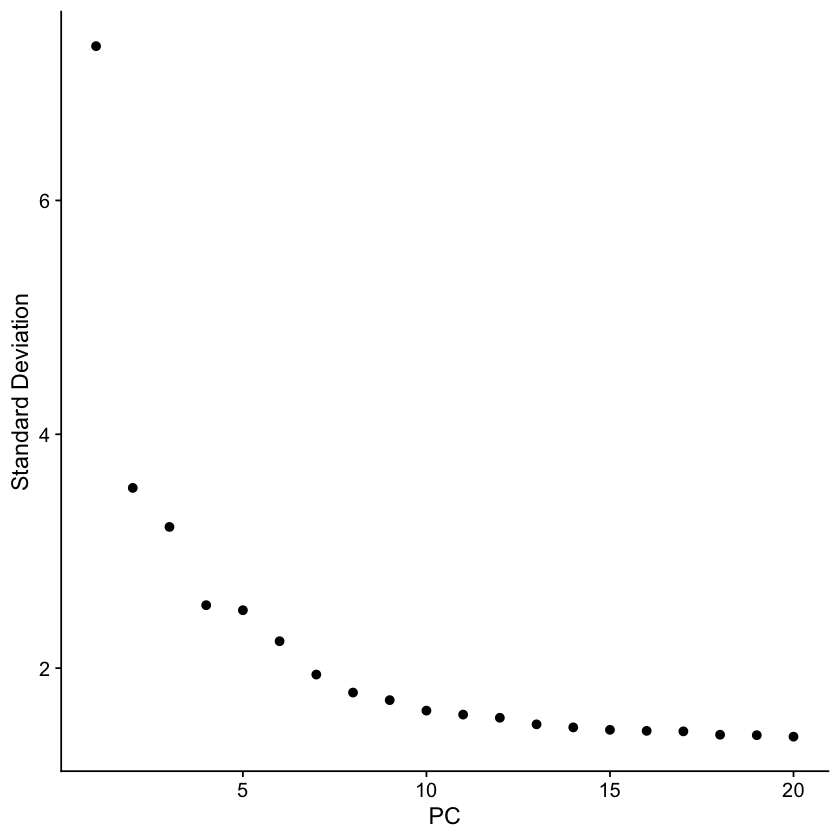

In [11]:
# 4. Run PCA
set.seed(123)
t_cells <- RunPCA(t_cells, features = VariableFeatures(t_cells))
ElbowPlot(t_cells)

### 2.1 Alternative Workflow: SCTransform (Advanced)
- この章はPCのmemoryがないと実施できません。
- JIAsyno_CITEseq_T_NK_after_SCT.rdsを\
  https://drive.google.com/drive/folders/1Lj05xfjvvTJc1dcPmumUWuufns-7WHV2?usp=drive_link \
  に保存しました。この章は飛ばして次の章から再開できます。

In [ ]:
# 1. Split the object by sample
t_cells_list <- SplitObject(t_cells, split.by = "sample")
# 2. Apply SCTransform to each sample individually
# (This may take a few minutes)
t_cells_list <- lapply(X = t_cells_list, FUN = function(x) {
  x <- SCTransform(x, verbose = FALSE)
  return(x)
})

# 3. Select common features for integration
# Since we want to compare subtypes across samples, we find genes that are
# consistently variable across all batches.
sct_features <- SelectIntegrationFeatures(object.list = t_cells_list, nfeatures = 2000)
# 4. Merge/Prepare for downstream analysis
# For Harmony-based workflows, we usually switch back to the main object but
# ensure the 'SCT' assay is used, or we carry forward the integrated features.
# Here, we run PCA on the combined SCT data.
t_cells <- merge(t_cells_list[[1]], y = t_cells_list[2:length(t_cells_list)])
VariableFeatures(t_cells) <- sct_features
# 5. Run PCA on SCT-normalized data
t_cells <- RunPCA(t_cells, assay = "SCT", npcs = 30)
DefaultAssay(t_cells)
ElbowPlot(t_cells)

output_filename <- "/Users/usename/Desktop/SingleCellWorkshop/data/JIAsyno_CITEseq_T_NK_after_SCT.rds"
saveRDS(t_cells, file = output_filename)
print(paste("Saved final T/NK object to:", output_filename))

### 3.Batch Correction (Harmony)

##前の章を飛ばした場合
https://drive.google.com/drive/folders/1Lj05xfjvvTJc1dcPmumUWuufns-7WHV2?usp=drive_link　\ 
のday2>JIAsyno_CITEseq_T_NK_after_SCT.rdsをSingleCellWorkshopフォルダに保存しこの章から再開してください。

In [12]:
t_cells <- readRDS("./JIAsyno_CITEseq_T_NK_after_SCT.rds")

In [13]:
if (!"sample" %in% colnames(t_cells@meta.data)) {
  t_cells$sample <- t_cells$orig.ident # Fallback
}
# Run Harmony
set.seed(123)
library(harmony)
t_cells <- RunHarmony(t_cells, group.by.vars = "sample", plot_convergence = FALSE)

library(lisi)
# Helper function to evaluate integration
evaluate_harmony <- function(obj, theta_val = 2, sigma_val = 0.1, lambda_val = 1, label = "") {
  # Run Harmony
  set.seed(123)
  obj_tmp <- RunHarmony(obj,
                        group.by.vars = "sample",
                        theta = theta_val, sigma = sigma_val, lambda = lambda_val,
                        plot_convergence = FALSE, verbose = FALSE
  )
  
  # Run UMAP for visualization
  set.seed(123)
  obj_tmp <- RunUMAP(obj_tmp, reduction = "harmony", dims = 1:20, verbose = FALSE)
  
  # Compute LISI scores (using harmony embeddings)
  # Note: we use the 'sample' for iLISI and 'seurat_clusters' (or existing labels) for cLISI
  # Since we haven't clustered yet, we use the original major_cell_type if available
  lisi_res <- compute_lisi(
    Embeddings(obj_tmp, "harmony"),
    obj_tmp@meta.data,
    c("sample", "ct")
  )
  
  obj_tmp$iLISI <- lisi_res$sample
  obj_tmp$cLISI <- lisi_res$ct
  
  return(list(obj = obj_tmp, label = label))
}

 要求されたパッケージ Rcpp をロード中です 

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


### 解説
ここでは同じ処理をtheta, sigma, lambdaを変えて何度も繰り返します。こういう時には関数をあらかじめ自分で定義するとコードが読みやすくなります。\
evaluate_harmonyという関数を定義し次で使用しています。 

theta=16を追加するためにここからcodeにアレンジを加えています。

エラーが出る場合は \
install.packages("ggplot2") \
install.packages("patchwork") \
を実施してから再開してみてください。

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


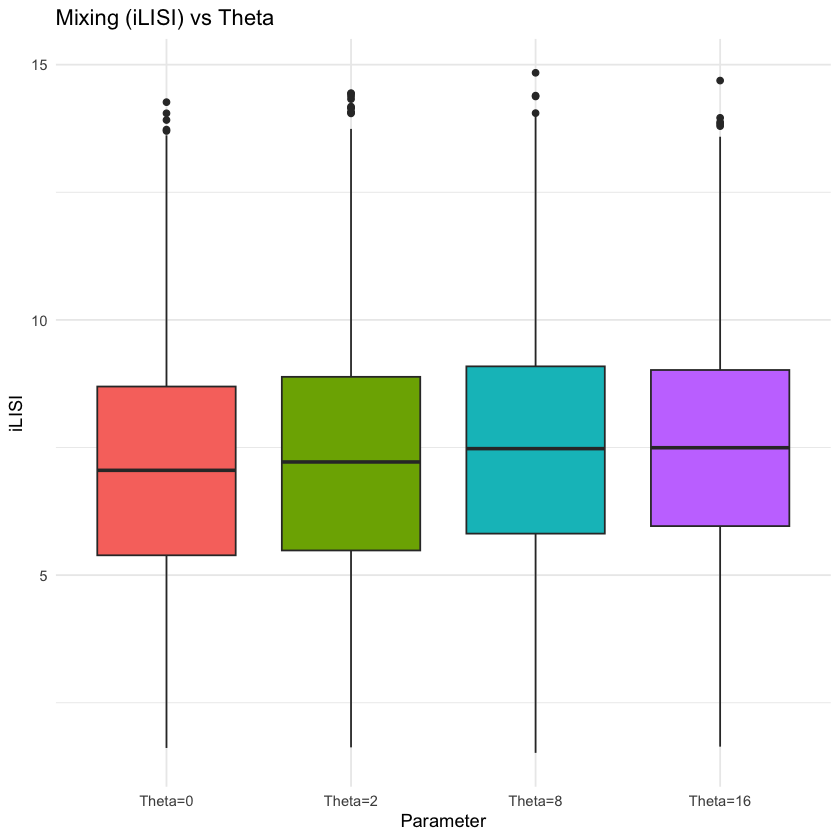

In [14]:
# 1. Compare Theta (Influence on Mixing)
res_t0 <- evaluate_harmony(t_cells, theta_val = 0, label = "Theta=0 (None)")
res_t2 <- evaluate_harmony(t_cells, theta_val = 2, label = "Theta=2 (Default)")
res_t8 <- evaluate_harmony(t_cells, theta_val = 8, label = "Theta=8 (Strong)")
res_t16 <- evaluate_harmony(t_cells, theta_val = 16, label = "Theta=16 (Very Strong)") 

# 2. Visualize UMAPs
library(ggplot2)
p1 <- DimPlot(res_t0$obj, reduction = "umap", group.by = "sample") + ggtitle(res_t0$label) + NoLegend()
p2 <- DimPlot(res_t2$obj, reduction = "umap", group.by = "sample") + ggtitle(res_t2$label) + NoLegend()
p3 <- DimPlot(res_t8$obj, reduction = "umap", group.by = "sample") + ggtitle(res_t8$label) + NoLegend()
p4 <- DimPlot(res_t8$obj, reduction = "umap", group.by = "sample") + ggtitle(res_t8$label)　

# 3. Quantify with LISI Boxplots
lisi_df <- data.frame(
  iLISI = c(res_t0$obj$iLISI, res_t2$obj$iLISI, res_t8$obj$iLISI, res_t16$obj$iLISI),
  Parameter = rep(c("Theta=0", "Theta=2", "Theta=8", "Theta=16"), each = ncol(t_cells))
)

p_lisi_theta <- ggplot(lisi_df, aes(x = Parameter, y = iLISI, fill = Parameter)) +
  geom_boxplot() +
  theme_minimal() +
  ggtitle("Mixing (iLISI) vs Theta") +
  NoLegend()

lisi_df$Parameter=factor(lisi_df$Parameter, c("Theta=0", "Theta=2", "Theta=8", "Theta=16"))

###ポイント: ここでParameterの順番をc("Theta=0", "Theta=2", "Theta=8", "Theta=16")の順と定義しています。それにより、図示するときにこの順で表示されます。
#factor関数は結構使うので今回覚えておくといいと思います！

p_lisi_theta <- ggplot(lisi_df, aes(x = Parameter, y = iLISI, fill = Parameter)) +
  geom_boxplot() +
  theme_minimal() +
  ggtitle("Mixing (iLISI) vs Theta") +
  NoLegend()
p_lisi_theta

# 4. Compare Lambda (Aggressiveness)
res_l01 <- evaluate_harmony(t_cells, lambda_val = 0.1, label = "Lambda=0.1 (Aggressive)")
res_l10 <- evaluate_harmony(t_cells, lambda_val = 10, label = "Lambda=10 (Conservative)")

p_lisi_lambda <- ggplot(data.frame(
  iLISI = c(res_l01$obj$iLISI, res_l10$obj$iLISI),
  Parameter = rep(c("Lambda=0.1", "Lambda=10"), each = ncol(t_cells))
), aes(x = Parameter, y = iLISI, fill = Parameter)) +
  geom_boxplot() +
  theme_minimal() +
  ggtitle("Mixing (iLISI) vs Lambda") +
  NoLegend()

# 5. Compare Sigma (Cluster Width)
res_s001 <- evaluate_harmony(t_cells, sigma_val = 0.01, label = "Sigma=0.01 (Local)")
res_s1 <- evaluate_harmony(t_cells, sigma_val = 1, label = "Sigma=1 (Global)")

p_lisi_sigma <- ggplot(data.frame(
  iLISI = c(res_s001$obj$iLISI, res_s1$obj$iLISI),
  Parameter = rep(c("Sigma=0.01", "Sigma=1"), each = ncol(t_cells))
), aes(x = Parameter, y = iLISI, fill = Parameter)) +
  geom_boxplot() +
  theme_minimal() +
  ggtitle("Mixing (iLISI) vs Sigma") +
  NoLegend()



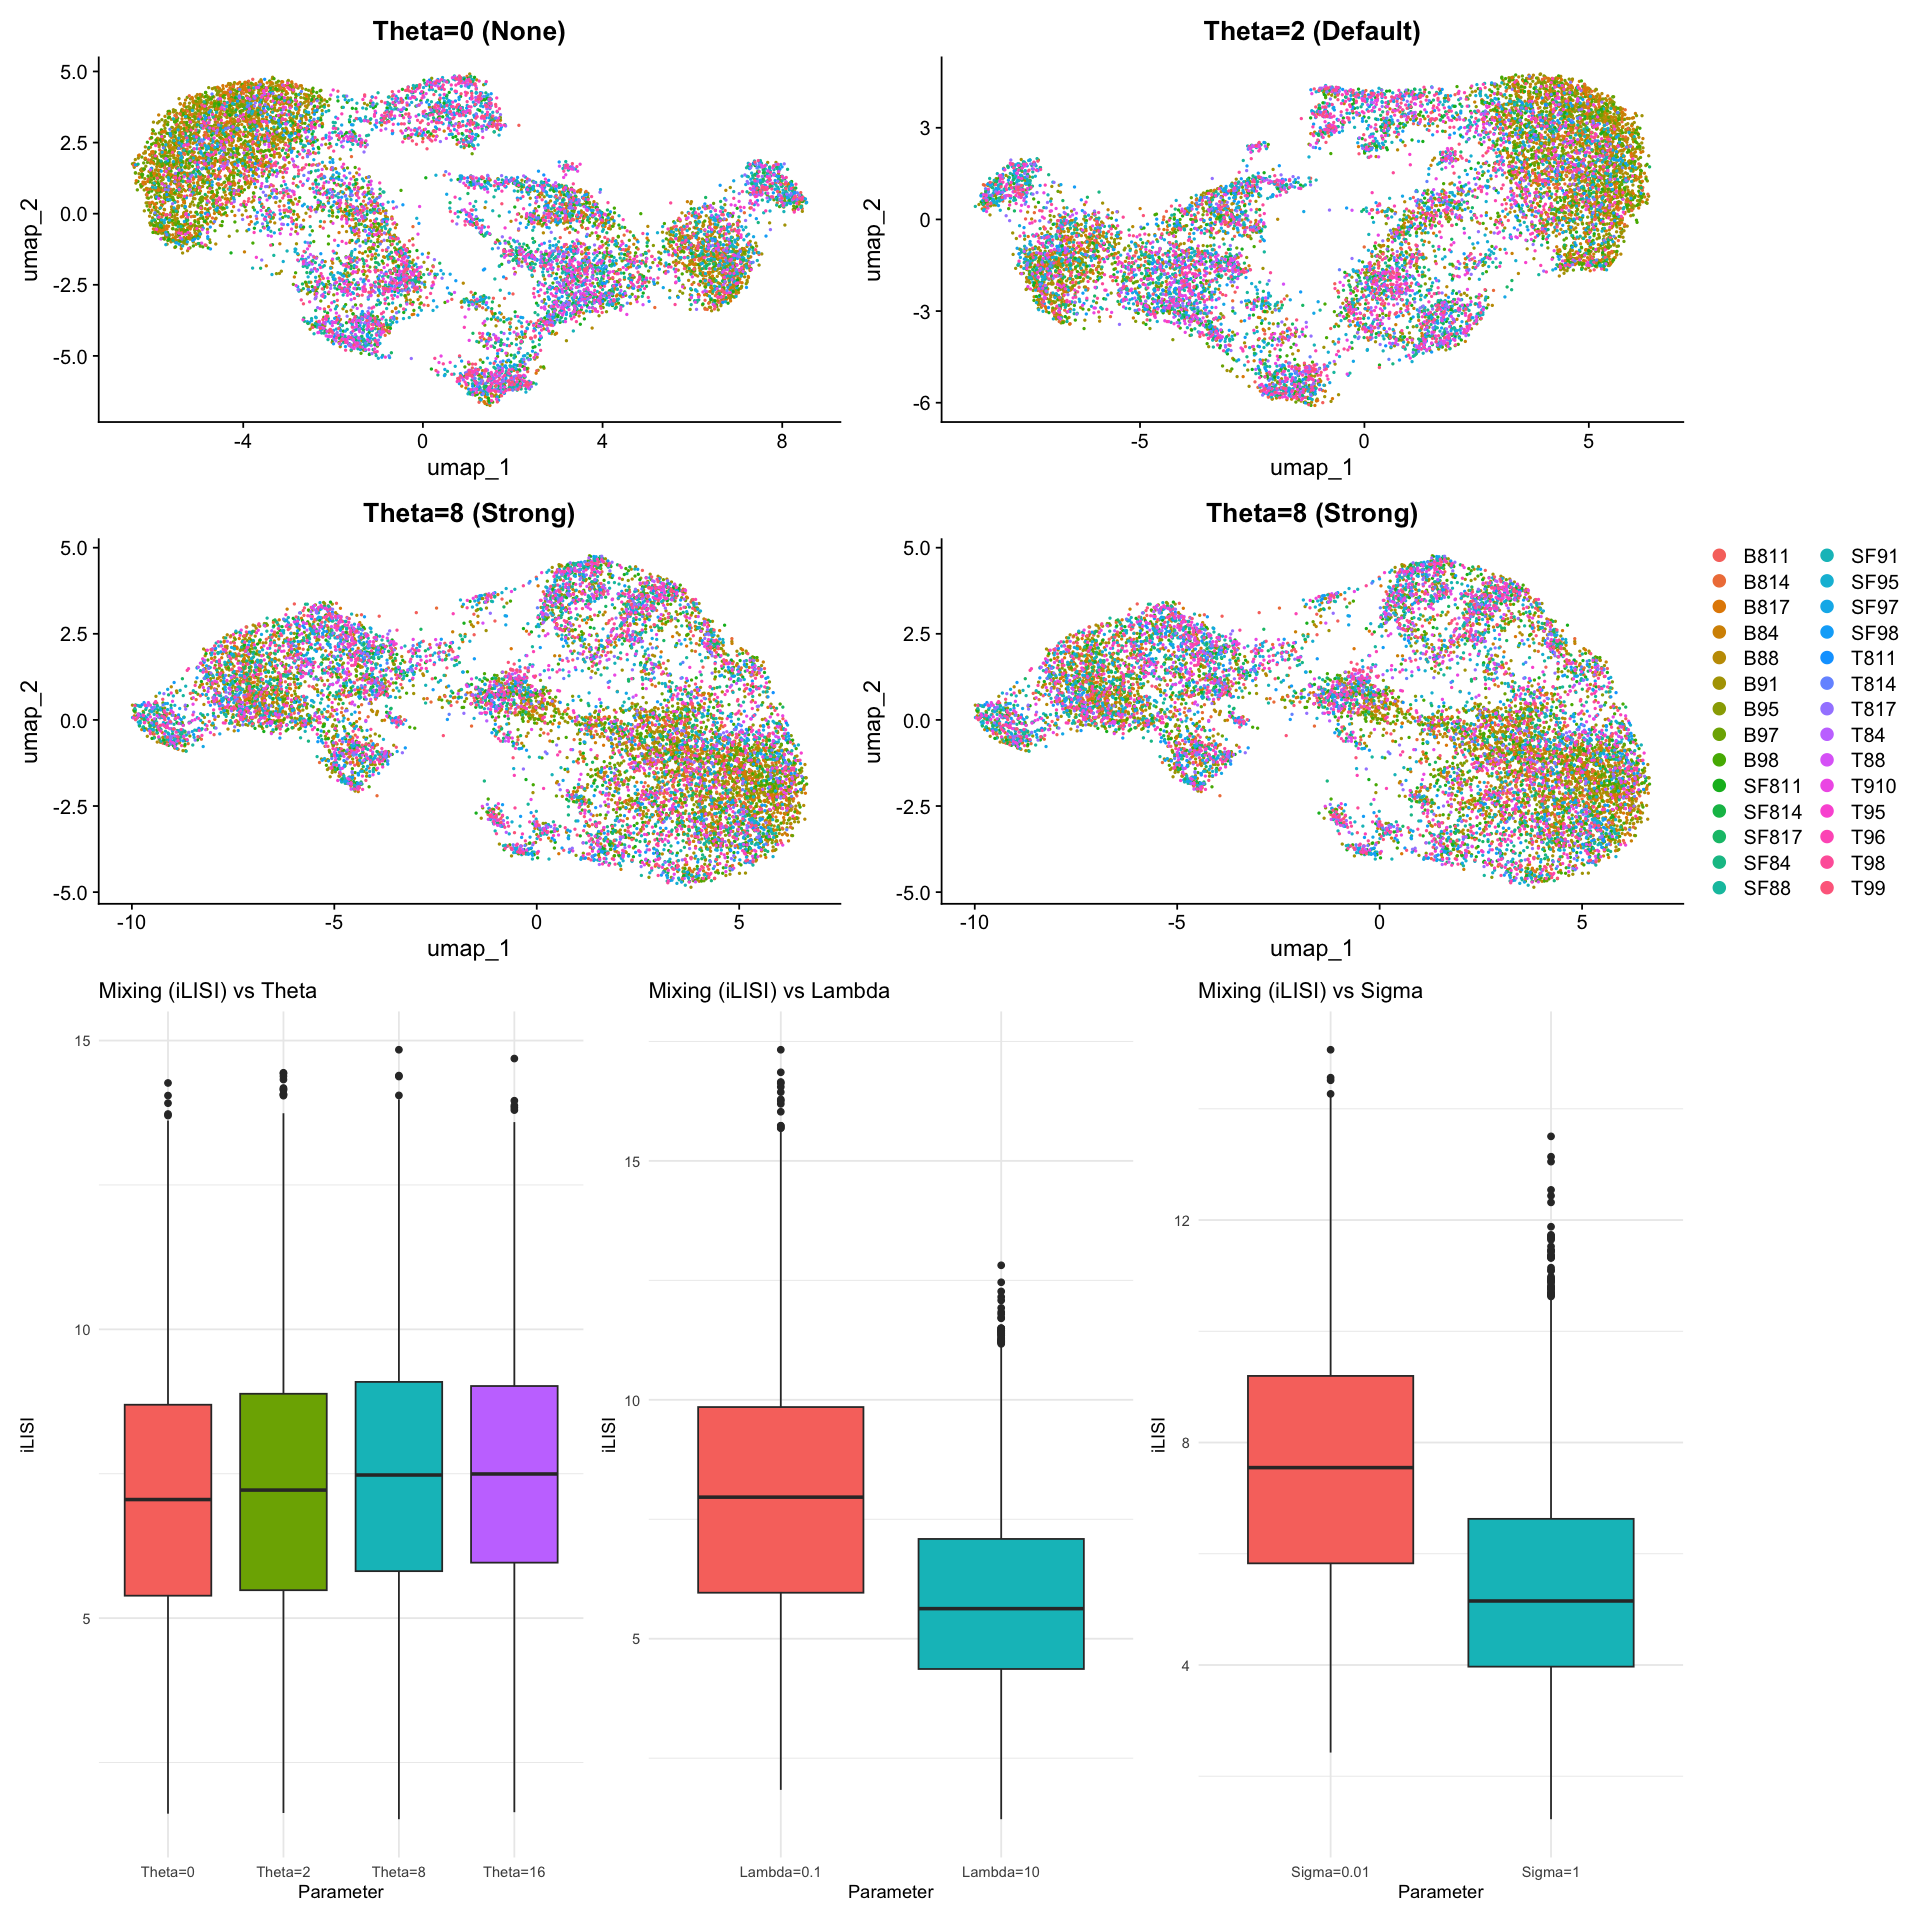

In [15]:
options(repr.plot.width=16, repr.plot.height=16)
(p1 + p2 + p3 + p4) / (p_lisi_theta + p_lisi_lambda + p_lisi_sigma)

###　おまけ
このtutorialのような表示方法をjupyter notebookと言います。
このような形式で今回作成した環境のRを使いたい場合のcodeです。

ターミナルで下記を実施
conda activate scworkshop
conda install jupyter
R  #これでR内に入ります
install.packages('IRkernel')
IRkernel::installspec(name = 'ir43', displayname = 'R_scworkshop')
q() #これでRから出ます

#これで準備完了です。

In [ ]:
以降jupyterで作業したいときは
conda activate scworkshop
jupyter notebook
とするとブラウザにjupyterが立ち上がります。
右上の"New"というタブを押し、"R_scworkshop"を選ぶと今回設定したR環境が使えます